# Task 2 - Total number of balls on top of the table

## Imports

In [6]:
# ─── Standard Library ───────────────────────────────────────
import os
import json
import time
import random
import csv
import warnings
from collections import defaultdict
from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings("ignore")

# ─── Numeric / Data ─────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Image Processing ───────────────────────────────────────
import cv2
from PIL import Image as PILImage, ImageOps

# ─── Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns


# ─── PyTorch Core ───────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ─── Torchvision ────────────────────────────────────────────
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as T          # newer augmentation API
from torchvision import models
from torchvision.models import (
    ResNet18_Weights, ResNet50_Weights,
    EfficientNet_B0_Weights, MobileNet_V3_Small_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights
)

# ─── Metrics ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Segmentation
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry


# ─── Roboflow (dataset download) ────────────────────────────
from roboflow import Roboflow

# ─── Misc Utilities ─────────────────────────────────────────
from tqdm.notebook import tqdm         # progress bars in Jupyter
from pathlib import Path
import itertools
import copy

# ─── Device Setup ───────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ─── MAX GPU PERFORMANCE ─────────────────────────────────────
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Use TF32 for faster matrix ops on Ampere+ (safe for inference)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Allocate as much VRAM as possible
torch.cuda.set_per_process_memory_fraction(0.95, device=0)

print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cuda
GPU: Quadro RTX 8000
VRAM available: 47.3 GB


## Download Dataset

In [8]:
# ─── DATASET DOWNLOAD ───────────────────────────────────────
DOWNLOAD_DATASETS = True  # Set to False if datasets are already downloaded

if DOWNLOAD_DATASETS:
    rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))

    datasets_dir = Path("datasets")
    datasets_dir.mkdir(exist_ok=True)

    # Original working dir
    original_dir = os.getcwd()
    
    all_datasets = [
        #("bachelorthesis",            "8-ball-pool-l530o"),        # main
        #("nidacorian-protonmail-com", "pool-billiard"),             # extra 1
        #("mark-dj0yk",               "pool-balls-detection-srlqi"),# extra 2
        #("pool-ball-detection",      "pool-ball-detection-6lfd9"), # extra 3
        #("cueball",         "tripod-height-pool-balls"),      # extra 4 
        #("testpool-3dxt6",      "pool-table-balls"),     # extra 5 
        #("testpool-3dxt6",   "pool-table-balls")          # table detection
        #("pooltafel", "pooltable-balls"), # top view images extra 6
        #("billiard-acbcc", "pool-billiard-nwmsh") # front view images extra 7
        ("pedro-marinho", "nine-balls-segmentation-abntv-0fyhm")  # extra 8 front view images
    ]

    for workspace_name, project_name in all_datasets:
        print(f"\n{'='*50}")
        print(f"Downloading: {workspace_name}/{project_name}")
        print(f"{'='*50}")
        
        try:
            project = rf.workspace(workspace_name).project(project_name)
            versions = project.versions()
            print(f"Found {len(versions)} version(s)")
            
            # Each dataset goes into its own subfolder
            project_dir = datasets_dir / project_name
            project_dir.mkdir(exist_ok=True)
            os.chdir(project_dir)

            latest_version = max(versions, key=lambda v: int(v.version))

            print(f"  -> Downloading version {latest_version.version}...")
            latest_version.download("coco")  # Download in COCO format
            
        except Exception as e:
            print(f"  [ERROR] Failed to download {project_name}: {e}")
        
        finally:
            os.chdir(original_dir)

    print(f"\nAll done! Datasets saved in: {datasets_dir.resolve()}")


Downloading: pedro-marinho/nine-balls-segmentation-abntv-0fyhm
loading Roboflow workspace...
loading Roboflow project...
Found 1 version(s)
  -> Downloading version 1...
Exporting format coco in progress : 34.0%
Version export complete for coco format



Extracting Dataset Version Zip to Nine-balls-segmentation-1 in coco:: 100%|██████████| 303/303 [00:00<00:00, 3243.85it/s]


All done! Datasets saved in: /home/admin/Documents/FEUP-CV/proj/task2/datasets


## Run Models

## 1 · Configuration
Edit the paths and hyper-parameters here — nowhere else needs changing.

In [ ]:
import os

# ── Configuration ──────────────────────────────────────────────────────────
TASK_MODE   = "classification"  # Options: "classification" or "regression"
NUM_CLASSES = 17                # 0 to 16 balls

# ── Paths (Static) ─────────────────────────────────────────────────────────
DATASET_ROOT = "../datasets"
CATALOG_JSON = "../datasets/task2/parsed_dataset_catalog.json" 

# ── Split ──────────────────────────────────────────────────────────────────
SPLIT_RATIOS = (0.80, 0.10, 0.10)       # train / val / test
SEED         = 42

# ── Training ───────────────────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 16
NUM_EPOCHS      = 50
LR              = 5e-4
WEIGHT_DECAY    = 1e-2
FREEZE_BACKBONE = False   # True = only train head (fast first pass)

# ── Dynamic Run Directory Setup ────────────────────────────────────────────
BASE_RESULTS_DIR = "results_task2"
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

existing_runs = [d for d in os.listdir(BASE_RESULTS_DIR) if d.startswith("run_")]
run_numbers = []
for d in existing_runs:
    try:
        run_numbers.append(int(d.split("_")[1]))
    except ValueError:
        pass

next_run_num = max(run_numbers) + 1 if run_numbers else 1
RUN_DIR = os.path.join(BASE_RESULTS_DIR, f"run_{next_run_num}")

# Create the subfolders for this specific run
MODELS_DIR = os.path.join(RUN_DIR, "models")
GRAPHS_DIR = os.path.join(RUN_DIR, "graphs")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(GRAPHS_DIR, exist_ok=True)

# Keep the CSV at the root of the RUN_DIR
RESULTS_CSV = os.path.join(RUN_DIR, "results.csv")

print(f"📁 Initialized new experiment folder: {RUN_DIR}")
print(f"   ├─ 🧠 Models:  {MODELS_DIR}")
print(f"   ├─ 📊 Graphs:  {GRAPHS_DIR}")
print(f"   └─ 📝 Results: {RESULTS_CSV}")
print("Config loaded ✓")

📁 Initialized new experiment folder: results_task2/run_22
   ├─ 🧠 Models:  results_task2/run_22/models
   ├─ 📊 Graphs:  results_task2/run_22/graphs
   └─ 📝 Results: results_task2/run_22/results.csv
Config loaded ✓


## 3 · Dataset & Stratified Split

In [4]:
# ── Load catalog ───────────────────────────────────────────────────────────
with open(CATALOG_JSON) as f:
    catalog = json.load(f)
print(f"Loaded {len(catalog):,} entries")

# ── Route data based on parser.py tags ─────────────────────────────────────
train_entries = []
val_entries   = []
test_entries  = []

for e in catalog:
    if e["type"] == "train":
        train_entries.append(e)
    elif e["type"] == "valid":
        val_entries.append(e)
    elif e["type"] == "test":
        test_entries.append(e)
    else:
        # Just a safety net in case there's a typo in the CSV
        train_entries.append(e) 

# Keep the random seeds for PyTorch initialization, but we don't use them for data splitting anymore
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Train: {len(train_entries):,}  |  Val: {len(val_entries):,}  |  Test: {len(test_entries):,}")

Loaded 247 entries
Train: 207  |  Val: 20  |  Test: 20


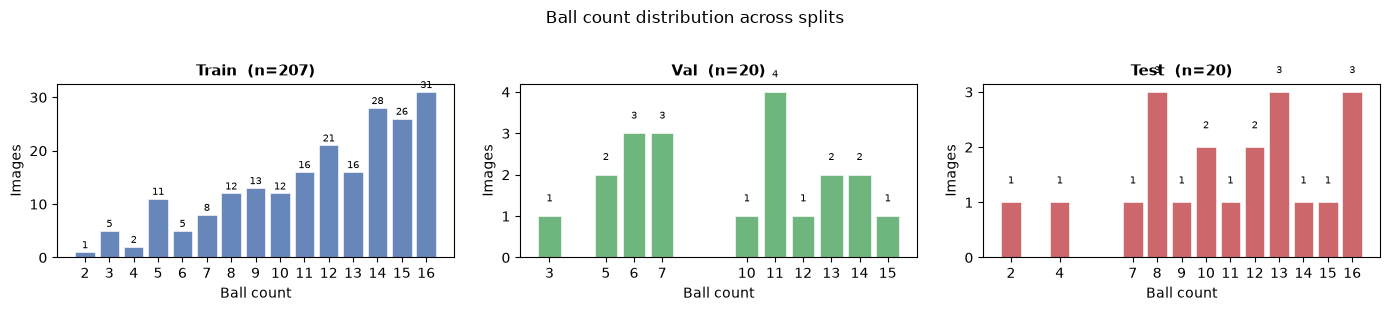

In [5]:
# ── Distribution plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)
split_data = [("Train", train_entries, "#4C72B0"),
              ("Val",   val_entries,   "#55A868"),
              ("Test",  test_entries,  "#C44E52")]

for ax, (name, entries, color) in zip(axes, split_data):
    counts = defaultdict(int)
    for e in entries:
        counts[e["ball_count"]] += 1
    x = sorted(counts.keys())
    y = [counts[k] for k in x]
    ax.bar(x, y, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name}  (n={len(entries):,})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Ball count")
    ax.set_ylabel("Images")
    ax.set_xticks(x)
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.3, str(yi), ha="center", va="bottom", fontsize=7)

plt.suptitle("Ball count distribution across splits", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4 · Transforms & PyTorch Dataset
Images come in **mixed resolutions** (416×416, 640×640, 1040×580, 1920×1080). `SquarePad` preserves aspect ratio before resizing.

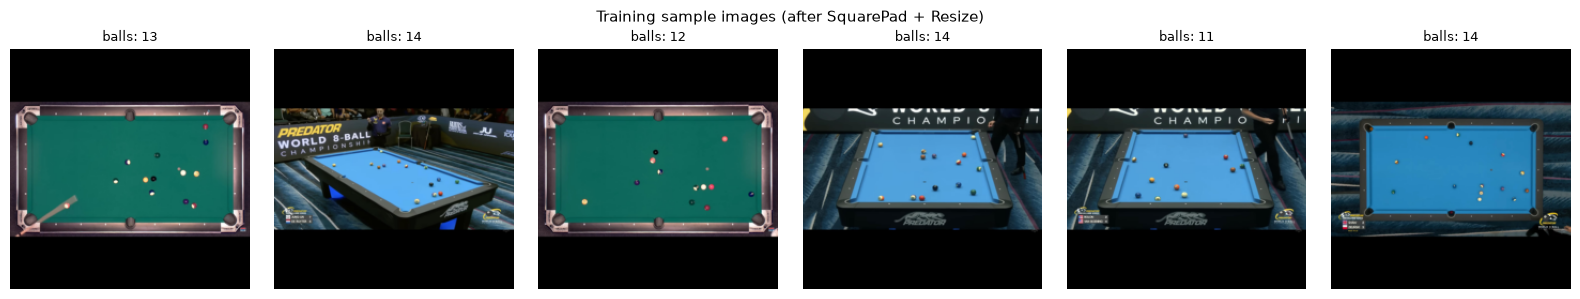

Dataset classes ready ✓


In [ ]:
# ── Transforms ─────────────────────────────────────────────────────────────
class SquarePad:
    """Pad the shorter side with black so the image becomes square."""
    def __call__(self, img):
        w, h    = img.size
        max_dim = max(w, h)
        pad_l   = (max_dim - w) // 2
        pad_t   = (max_dim - h) // 2
        pad_r   = max_dim - w - pad_l
        pad_b   = max_dim - h - pad_t
        return ImageOps.expand(img, (pad_l, pad_t, pad_r, pad_b), fill=0)

def make_transforms(train: bool) -> transforms.Compose:
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    
    if train:
        return transforms.Compose([
            SquarePad(),
            # Resize directly to IMG_SIZE (no padding for crops needed)
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(), # Safe for top-down/angled pool tables
            transforms.RandomRotation(25),   # Safe spatial augmentation
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.02),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            SquarePad(),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

# ── Dataset ────────────────────────────────────────────────────────────────
class BallCountDataset(Dataset):
    def __init__(self, entries, root, transform=None):
        self.entries   = entries
        self.root      = root
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        e        = self.entries[idx]
        img_path = os.path.join(self.root, e["path"])
        
        try:
            img = PILImage.open(img_path).convert('RGB')
        except Exception:
            img = PILImage.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
            
        if self.transform:
            img = self.transform(img)
            
        # Dynamically cast the label based on the flag
        if TASK_MODE == "classification":
            label = torch.tensor(int(e["ball_count"]), dtype=torch.long)
        else:
            label = torch.tensor(float(e["ball_count"]), dtype=torch.float32)
            
        return img, label


# ── Quick sanity-check: show 6 training images ─────────────────────────────
sample_ds = BallCountDataset(train_entries[50:56], DATASET_ROOT,
                             transforms.Compose([SquarePad(),
                                                 transforms.Resize((IMG_SIZE, IMG_SIZE))]))
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    img, lbl = sample_ds[i]
    ax.imshow(img)
    ax.set_title(f"balls: {int(lbl)}", fontsize=9)
    ax.axis("off")
plt.suptitle("Training sample images (after SquarePad + Resize)", fontsize=11)
plt.tight_layout()
plt.show()

print("Dataset classes ready ✓")

## 5 · Model Definitions
Add or remove entries from `MODELS` — that's the only thing you need to change.

In [ ]:
def _head(in_features):
    out_features = NUM_CLASSES if TASK_MODE == "classification" else 1
    return nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, out_features),
    )

def build_simple_cnn():
    out_features = NUM_CLASSES if TASK_MODE == "classification" else 1
    m = nn.Sequential(
        nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, out_features),
    )
    for layer in m.modules():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
    return m

def build_resnet18():
    m = models.resnet18(weights=ResNet18_Weights.DEFAULT, progress=True)
    m.fc = _head(m.fc.in_features)
    return m

def build_resnet50():
    m = models.resnet50(weights=ResNet50_Weights.DEFAULT, progress=True)
    m.fc = _head(m.fc.in_features)
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT, progress=True)
    m.classifier = _head(m.classifier[1].in_features)
    return m

def build_mobilenet_v3():
    m = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT, progress=True)
    m.classifier = _head(m.classifier[0].in_features)
    return m

def build_convnext_tiny():
    from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
    m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT, progress=True)
    in_features = m.classifier[2].in_features
    m.classifier[2] = _head(in_features)
    return m

def build_convnext_base():
    from torchvision.models import convnext_base, ConvNeXt_Base_Weights
    m = convnext_base(weights=ConvNeXt_Base_Weights.DEFAULT, progress=True)
    in_features = m.classifier[2].in_features
    m.classifier[2] = _head(in_features)
    return m

def build_convnext_large():
    from torchvision.models import convnext_large, ConvNeXt_Large_Weights
    m = convnext_large(weights=ConvNeXt_Large_Weights.DEFAULT, progress=True)
    in_features = m.classifier[2].in_features
    m.classifier[2] = _head(in_features)
    return m

def build_vit_b_16():
    from torchvision.models import vit_b_16, ViT_B_16_Weights
    m = vit_b_16(weights=ViT_B_16_Weights.DEFAULT, progress=True)
    # ViT uses a different internal naming structure for its final layer
    in_features = m.heads.head.in_features
    m.heads.head = _head(in_features)
    return m

# ── MODEL REGISTRY — edit here ─────────────────────────────────────────────
MODELS = [
    # These arent so good
    #("SimpleCNN",        build_simple_cnn),
    #("EfficientNet_B0",  build_efficientnet_b0),
    #("MobileNetV3",      build_mobilenet_v3),
    # Tested these are the best
    #("ResNet18",         build_resnet18), 
    #("ResNet50",         build_resnet50),
    ("ConvNeXt_Tiny",    build_convnext_tiny),
    # These are the new ones we want to test
    #("ConvNeXt_Base",    build_convnext_base),
    #("ConvNeXt_Large",   build_convnext_large),
    #("ViT_B_16",         build_vit_b_16),
]

# ── Parameter count summary ────────────────────────────────────────────────
print(f"{'Model':<20} {'Parameters':>12}")
print("-" * 34)
for name, builder in MODELS:
    m      = builder()
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:<20} {params:>12,}")

Model                  Parameters
----------------------------------
ResNet18               11,312,209


ResNet50               24,036,945
ConvNeXt_Tiny          28,021,361


## 6 · Training & Evaluation Helpers

In [8]:
def compute_metrics(preds: np.ndarray, labels: np.ndarray) -> dict:
    mae    = float(np.mean(np.abs(preds - labels)))
    mse    = float(np.mean((preds - labels) ** 2))
    rmse   = float(np.sqrt(mse))
    acc1   = float(np.mean(np.abs(np.round(preds) - labels) <= 1))
    exact  = float(np.mean(np.round(preds) == labels))
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "Acc@1": acc1, "ExactAcc": exact}

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0
    
    # Just loop directly over the loader, no tqdm
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        if (labels < 0).any() or (labels >= NUM_CLASSES).any():
            print(f"CRITICAL ERROR: Found label out of bounds! Labels: {labels}")
            assert False, "Label out of bounds found!"
            
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(imgs)
        
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_preds, all_labels, total = [], [], 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(imgs)
        if TASK_MODE == "classification":
            loss = criterion(outputs, labels)
            # Extract the class with the highest probability
            preds = torch.argmax(outputs, dim=1).float() 
        else:
            loss = criterion(outputs.squeeze(1), labels)
            preds = outputs.squeeze(1)
            
        total += loss.item() * len(imgs)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.float().cpu().numpy())
        
    return (total / len(loader.dataset),
            np.concatenate(all_preds),
            np.concatenate(all_labels))

print("Helpers ready ✓")

Helpers ready ✓


## 7 · Training Loop
Runs every model in `MODELS` sequentially. Best val-loss checkpoint is saved automatically.

In [ ]:
# ── Prepare DataLoaders ONCE ───────────────────────────────────────────────
print("Initializing Datasets and DataLoaders...")
train_ds = BallCountDataset(train_entries, DATASET_ROOT, make_transforms(True))
val_ds   = BallCountDataset(val_entries,   DATASET_ROOT, make_transforms(False))
test_ds  = BallCountDataset(test_entries,  DATASET_ROOT, make_transforms(False))

# Setting pin_memory=True and num_workers=4 is great for performance
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Training Setup ─────────────────────────────────────────────────────────
all_results   = []   # list of dicts for the final comparison
history_store = {}   # {model_name: {"train": [...], "val": [...]}}

ACTIVE_DATASETS = os.getenv("ACTIVE_DATASETS", "main_dataset")

csv_fields = ["model", "datasets_used", "MAE", "MSE", "RMSE", "Acc@1", "ExactAcc"]
with open(RESULTS_CSV, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=csv_fields).writeheader()

# ── Multi-Model Training Loop ──────────────────────────────────────────────
for model_name, builder in MODELS:
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    # ── Model Initialization ───────────────────────────────────────
    model = builder().to(DEVICE)
    if FREEZE_BACKBONE and model_name != "SimpleCNN":
        for n, p in model.named_parameters():
            if "fc" not in n and "classifier" not in n:
                p.requires_grad = False
    
    if TASK_MODE == "classification":
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.MSELoss()
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val  = float("inf")
    ckpt_path = os.path.join(MODELS_DIR, f"{model_name}_best.pth")
    history   = {"train": [], "val": []}

    # ── Epoch Loop ─────────────────────────────────────────────────
    for epoch in range(1, NUM_EPOCHS + 1):
        # Remove the 'epoch' argument here since we stripped tqdm
        t_loss            = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, _, _      = evaluate(model, val_loader, criterion)
        scheduler.step()
        
        history["train"].append(t_loss)
        history["val"].append(v_loss)

        marker = ""
        if v_loss < best_val:
            best_val = v_loss
            torch.save(model.state_dict(), ckpt_path)
            marker = " ← ✓"

        # REMOVE the 'if epoch % 5 == 0' check. Just print every epoch!
        print(f"  [{epoch:3d}/{NUM_EPOCHS}]  "
              f"train={t_loss:.4f}  val={v_loss:.4f}{marker}")

    history_store[model_name] = history

    # ── Test Evaluation ────────────────────────────────────────────
    # Load the best weights before testing
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    _, preds, labels = evaluate(model, test_loader, criterion)
    
    metrics = compute_metrics(preds, labels)
    metrics["preds"]  = preds     # store for later plotting
    metrics["labels"] = labels
    metrics["model"]  = model_name
    all_results.append(metrics)

    # ── Append to CSV ──────────────────────────────────────────────
    with open(RESULTS_CSV, "a", newline="") as f:
        row = {k: round(metrics[k], 5) for k in csv_fields[2:]}
        row["model"] = model_name
        row["datasets_used"] = ACTIVE_DATASETS
        csv.DictWriter(f, fieldnames=csv_fields).writerow(row)

    print(f"\n  Test →  MAE={metrics['MAE']:.3f}  RMSE={metrics['RMSE']:.3f}  "
          f"Acc@1={metrics['Acc@1']:.3f}  ExactAcc={metrics['ExactAcc']:.3f}")
          
    # ── VRAM Cleanup ───────────────────────────────────────────────
    # Force delete the model and clear CUDA cache so the next 
    # architecture doesn't cause an OutOfMemory error
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(f"\n\nAll models done! Results saved to {RESULTS_CSV}")

Initializing Datasets and DataLoaders...

  Training: ResNet18
  [  1/30]  train=2.7730  val=2.7434 ← ✓
  [  2/30]  train=2.5393  val=2.7205 ← ✓
  [  3/30]  train=2.4818  val=2.7191 ← ✓
  [  4/30]  train=2.3346  val=2.6991 ← ✓
  [  5/30]  train=2.2702  val=2.6520 ← ✓
  [  6/30]  train=2.1628  val=2.6874
  [  7/30]  train=2.0710  val=2.6228 ← ✓
  [  8/30]  train=2.0522  val=2.5770 ← ✓
  [  9/30]  train=1.9777  val=2.6155
  [ 10/30]  train=1.8740  val=2.5048 ← ✓
  [ 11/30]  train=1.8508  val=2.4270 ← ✓
  [ 12/30]  train=1.7920  val=2.3877 ← ✓
  [ 13/30]  train=1.7212  val=2.4304
  [ 14/30]  train=1.6449  val=2.4263
  [ 15/30]  train=1.6075  val=2.4040
  [ 16/30]  train=1.5723  val=2.4220
  [ 17/30]  train=1.5519  val=2.3463 ← ✓
  [ 18/30]  train=1.4618  val=2.3781
  [ 19/30]  train=1.4827  val=2.4007
  [ 20/30]  train=1.3724  val=2.4140
  [ 21/30]  train=1.3512  val=2.4087
  [ 22/30]  train=1.3230  val=2.4446
  [ 23/30]  train=1.3297  val=2.4458
  [ 24/30]  train=1.2185  val=2.4510
  [ 2

## 8 · Loss Curves

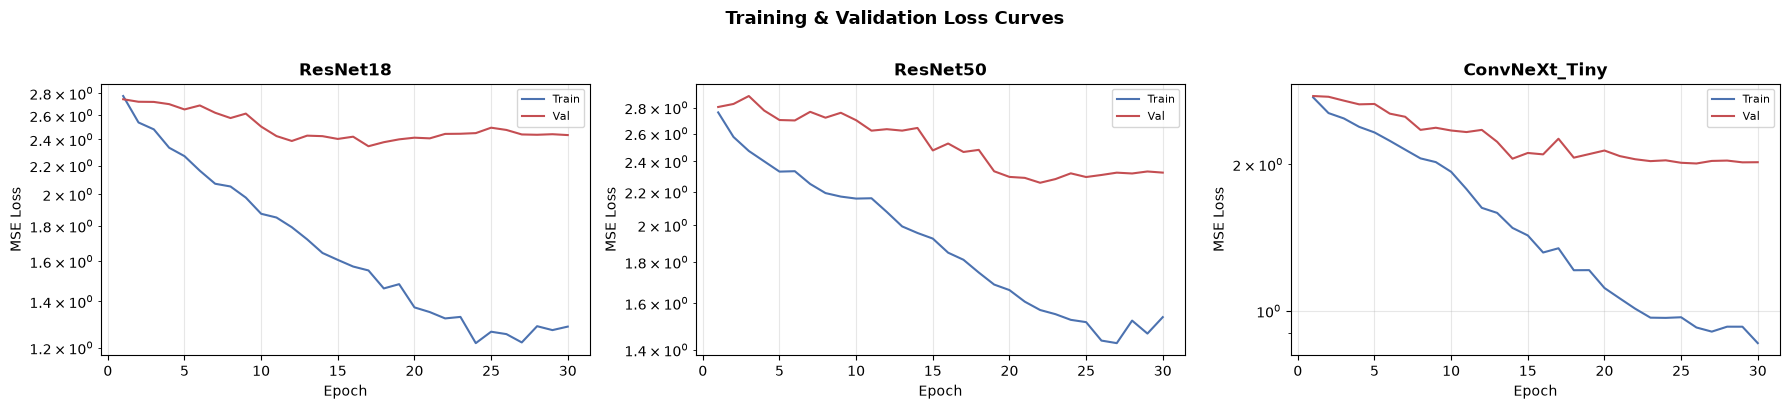

Saved: loss_curves.png


In [10]:
n_models = len(MODELS)
cols     = min(3, n_models)
rows     = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten()

for i, (name, _) in enumerate(MODELS):
    ax  = axes[i]
    h   = history_store[name]
    eps = range(1, len(h["train"]) + 1)
    ax.plot(eps, h["train"], label="Train", color="#4C72B0", linewidth=1.5)
    ax.plot(eps, h["val"],   label="Val",   color="#C44E52", linewidth=1.5)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Training & Validation Loss Curves", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_curves.png")

## 9 · Predictions vs Ground Truth (Test Set)

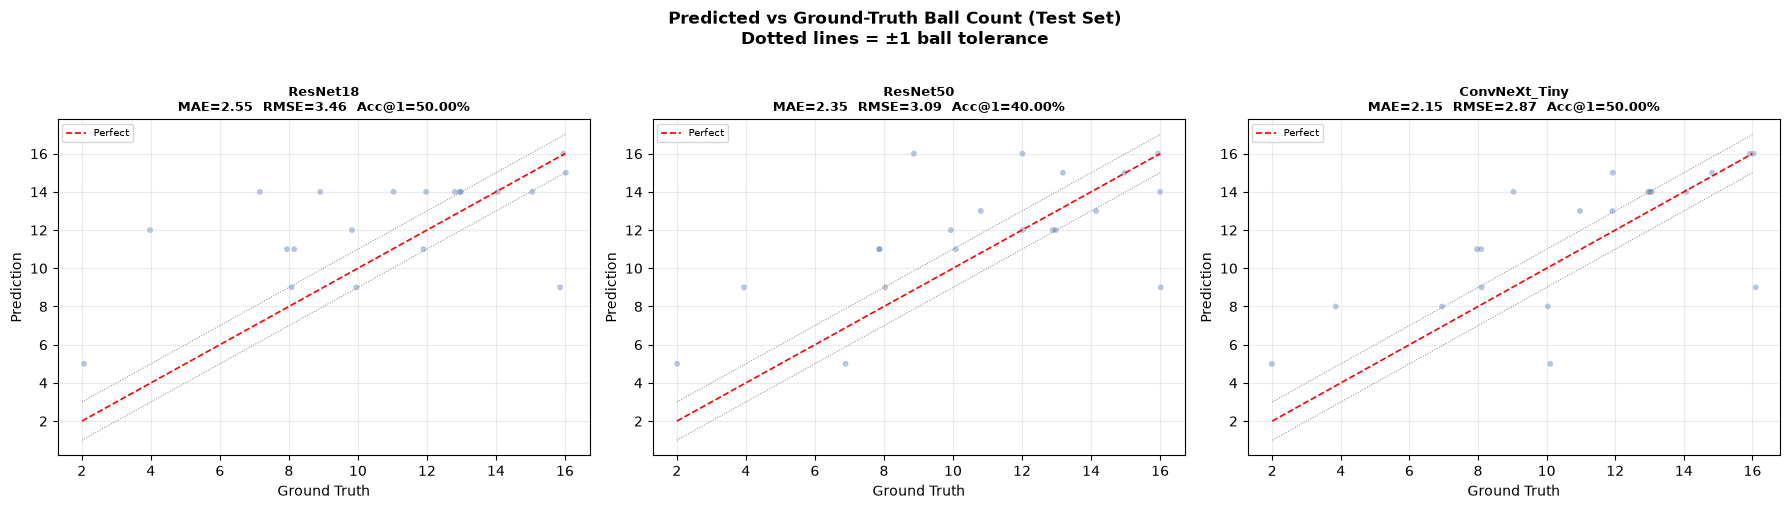

Saved: scatter_plots.png


In [11]:
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).flatten()

for i, res in enumerate(all_results):
    ax     = axes[i]
    preds  = res["preds"]
    labels = res["labels"]
    vmin, vmax = labels.min(), labels.max()

    jittered_labels = labels + np.random.normal(0, 0.1, size=labels.shape)
    ax.scatter(jittered_labels, preds, alpha=0.4, s=18, color="#4C72B0", edgecolors="none")
    ax.plot([vmin, vmax], [vmin, vmax], "r--", linewidth=1.2, label="Perfect")
    ax.plot([vmin, vmax], [vmin+1, vmax+1], "gray", linewidth=0.7, linestyle=":")
    ax.plot([vmin, vmax], [vmin-1, vmax-1], "gray", linewidth=0.7, linestyle=":")

    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_title(
        f"{res['model']}\n"
        f"MAE={res['MAE']:.2f}  RMSE={res['RMSE']:.2f}  "
        f"Acc@1={res['Acc@1']:.2%}",
        fontsize=9, fontweight="bold"
    )
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Predicted vs Ground-Truth Ball Count (Test Set)\n"
             "Dotted lines = ±1 ball tolerance", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "scatter_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: scatter_plots.png")

## 10 · Error Distribution per Model

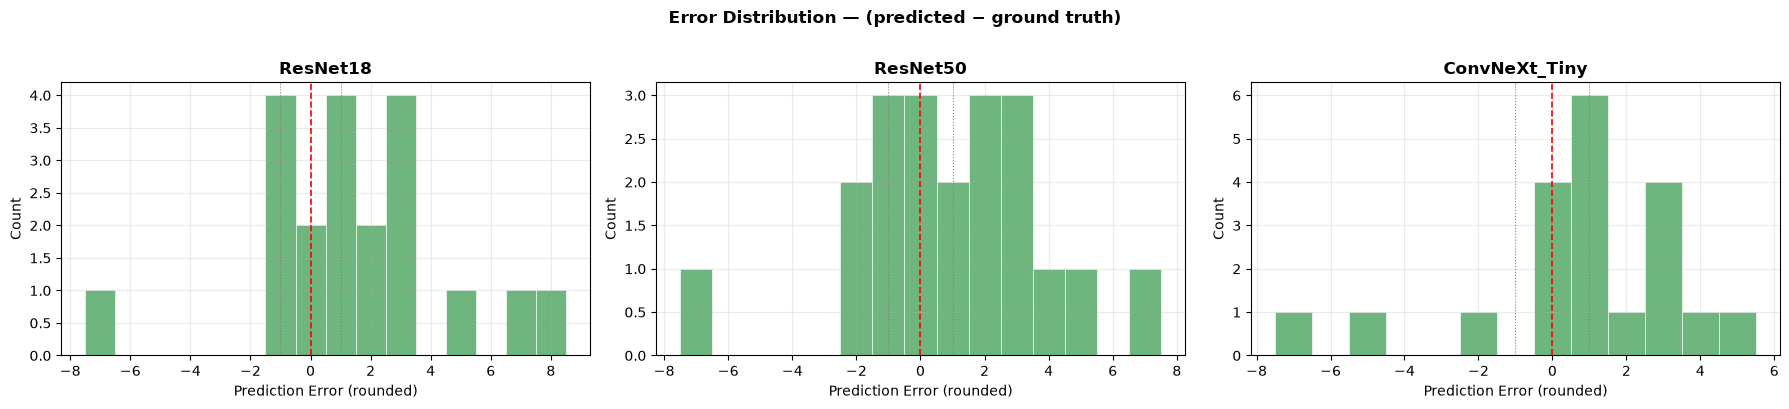

Saved: error_distributions.png


In [12]:
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten()

for i, res in enumerate(all_results):
    ax     = axes[i]
    errors = np.round(res["preds"]) - res["labels"]
    bins   = np.arange(errors.min() - 0.5, errors.max() + 1.5, 1)
    ax.hist(errors, bins=bins, color="#55A868", edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--")
    ax.axvline(-1, color="gray", linewidth=0.8, linestyle=":")
    ax.axvline(+1, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Prediction Error (rounded)")
    ax.set_ylabel("Count")
    ax.set_title(f"{res['model']}", fontweight="bold")
    ax.grid(alpha=0.25)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Error Distribution — (predicted − ground truth)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "error_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_distributions.png")

## 11 · Summary Table & Model Comparison

In [13]:
metrics_keys = ["MAE", "RMSE", "Acc@1", "ExactAcc"]
summary = pd.DataFrame([
    {
        "Model":    r["model"],
        "MAE ↓":   round(r["MAE"],     3),
        "RMSE ↓":  round(r["RMSE"],    3),
        "Acc@1 ↑": round(r["Acc@1"],   3),
        "Exact ↑": round(r["ExactAcc"],3),
    }
    for r in all_results
])
summary = summary.sort_values("RMSE ↓").reset_index(drop=True)
summary.index += 1   # rank starts at 1
print(summary.to_string())
summary

           Model  MAE ↓  RMSE ↓  Acc@1 ↑  Exact ↑
1  ConvNeXt_Tiny   2.15   2.872      0.5     0.20
2       ResNet50   2.35   3.090      0.4     0.15
3       ResNet18   2.55   3.457      0.5     0.10


,Model,MAE ↓,RMSE ↓,Acc@1 ↑,Exact ↑
1,ConvNeXt_Tiny,2.15,2.872,0.5,0.20
2,ResNet50,2.35,3.090,0.4,0.15
3,ResNet18,2.55,3.457,0.5,0.10


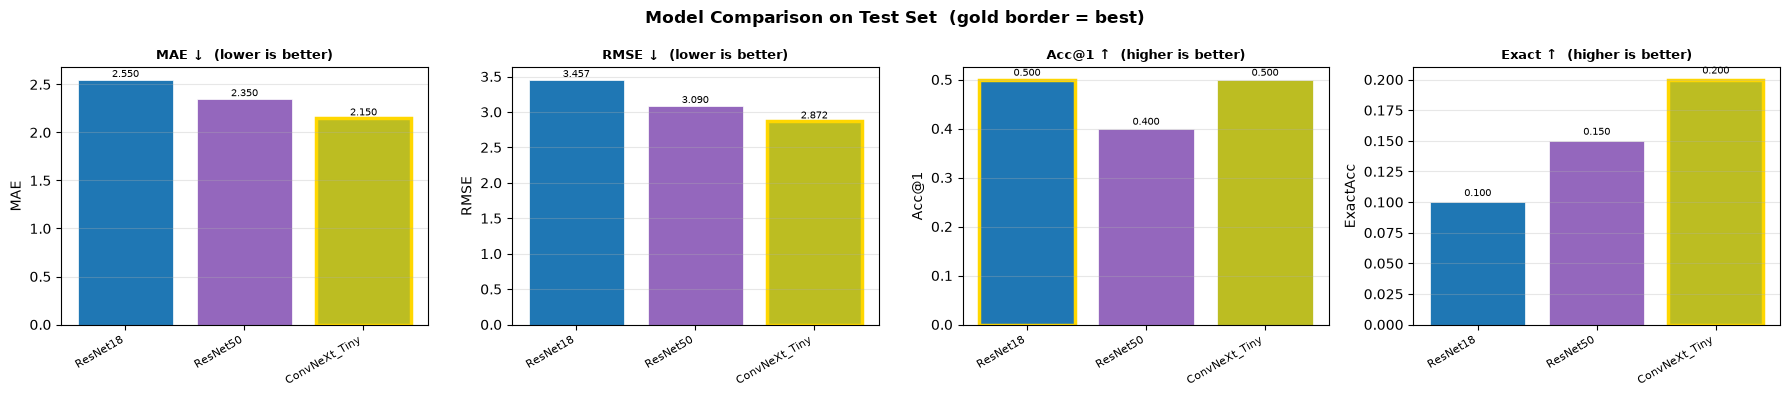

Saved: model_comparison.png


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_names = [r["model"] for r in all_results]
colors      = plt.cm.tab10(np.linspace(0, 0.8, len(all_results)))

plot_cfg = [
    ("MAE",      "MAE ↓  (lower is better)",   True,  axes[0]),
    ("RMSE",     "RMSE ↓  (lower is better)",  True,  axes[1]),
    ("Acc@1",    "Acc@1 ↑  (higher is better)",False, axes[2]),
    ("ExactAcc", "Exact ↑  (higher is better)",False, axes[3]),
]

for metric, title, lower_better, ax in plot_cfg:
    values = [r[metric] for r in all_results]
    bars   = ax.bar(model_names, values, color=colors, edgecolor="white", linewidth=0.5)
    best_i = np.argmin(values) if lower_better else np.argmax(values)
    bars[best_i].set_edgecolor("gold")
    bars[best_i].set_linewidth(2.5)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Model Comparison on Test Set  (gold border = best)", 
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

## 12 · Inference with the Best Model
Run this cell on any new image to get a ball count prediction.

📊 Final Model Rankings saved to CSV:
 Rank         model  MAE   MSE    RMSE  Acc@1  ExactAcc
    1 ConvNeXt_Tiny 2.15  8.25 2.87228    0.5      0.20
    2      ResNet50 2.35  9.55 3.09031    0.4      0.15
    3      ResNet18 2.55 11.95 3.45688    0.5      0.10
------------------------------------------------------------
🏆 Best model: ConvNeXt_Tiny  (ExactAcc=0.200)


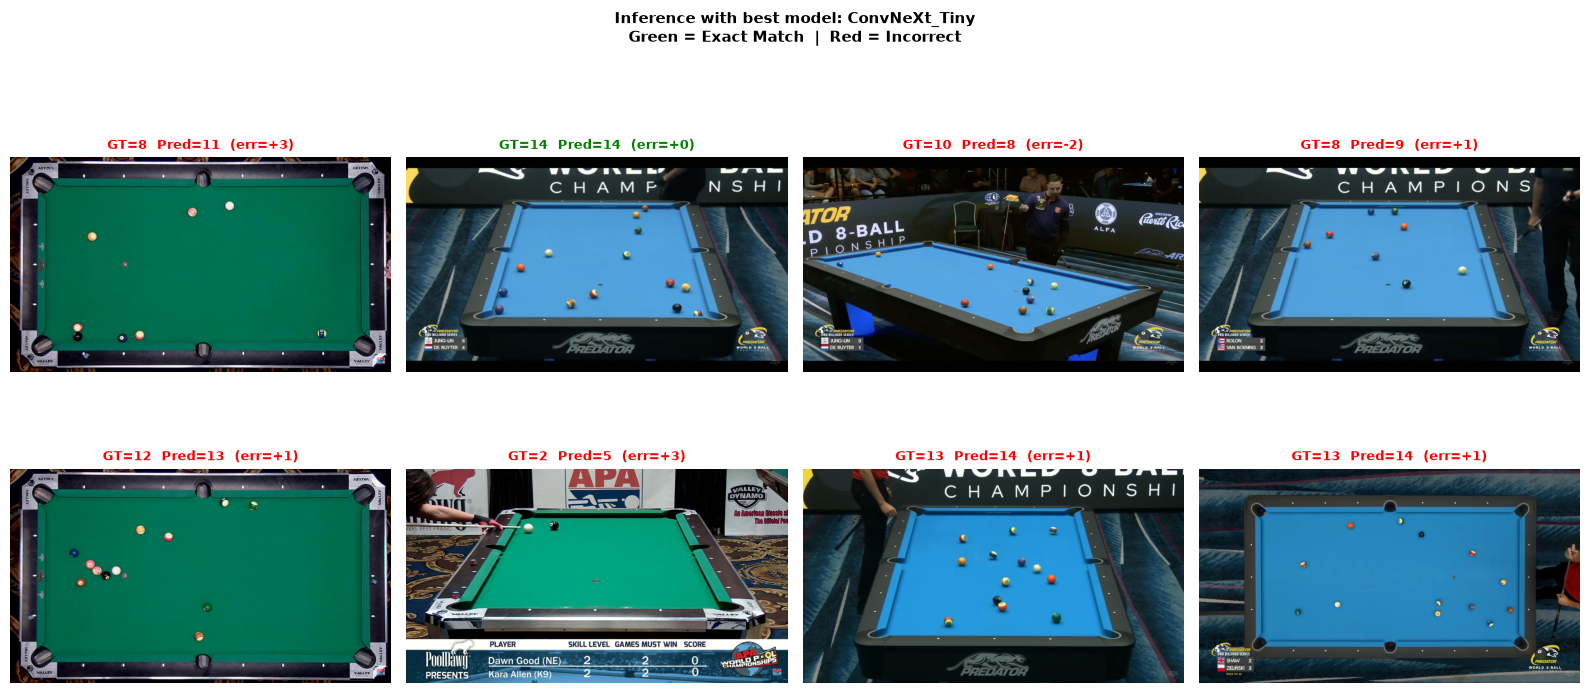

In [15]:
# ── Rank and Save Results to CSV ───────────────────────────────────────────
df = pd.read_csv(RESULTS_CSV)

# Sort: Primary = ExactAcc (descending), Secondary tie-breaker = RMSE (ascending)
df_ranked = df.sort_values(by=["ExactAcc", "RMSE"], ascending=[False, True]).reset_index(drop=True)

# Add a Rank column at the very front
if "Rank" not in df_ranked.columns:
    df_ranked.insert(0, "Rank", df_ranked.index + 1)
else:
    df_ranked["Rank"] = df_ranked.index + 1

# Overwrite the original CSV with the ranked version
df_ranked.to_csv(RESULTS_CSV, index=False)

print("📊 Final Model Rankings saved to CSV:")
print(df_ranked.to_string(index=False))
print("-" * 60)

# ── Pick best model ────────────────────────────────────────────────────────
# The best model is now simply the first row of our ranked DataFrame!
best_name = df_ranked.iloc[0]["model"]
best_exact = df_ranked.iloc[0]["ExactAcc"]
best_ckpt = os.path.join(MODELS_DIR, f"{best_name}_best.pth")

print(f"🏆 Best model: {best_name}  (ExactAcc={best_exact:.3f})")

# rebuild model from registry
best_builder = dict(MODELS)[best_name]
best_model   = best_builder().to(DEVICE)
best_model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
best_model.eval()

infer_transform = make_transforms(train=False)

def predict_ball_count(img_path: str) -> dict:
    """Return predicted ball count (int) and raw output."""
    try:
        img = PILImage.open(img_path).convert('RGB') 
    except FileNotFoundError:                       
        raise FileNotFoundError(f"Cannot load: {img_path}")
    except Exception as e:                          
        raise RuntimeError(f"Unexpected error loading image: {e}")
        
    tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        outputs = best_model(tensor)
        
        if TASK_MODE == "classification":
            pred = torch.argmax(outputs, dim=1).item()
            raw = pred 
        else:
            raw = outputs.squeeze().item()
            pred = round(raw)
            
    return {"raw": raw, "predicted": pred}


# ── Quick test on a few images from the test set ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes      = axes.flatten()
sample    = random.sample(test_entries, min(8, len(test_entries)))

for ax, entry in zip(axes, sample):
    img_path = os.path.join(DATASET_ROOT, entry["path"])
    result   = predict_ball_count(img_path)
    gt       = entry["ball_count"]
    err      = result["predicted"] - gt
    
    # Strict grading visualization! Only green if perfect match.
    color    = "green" if err == 0 else "red"

    # We can just use PIL here too for the display!
    img = PILImage.open(img_path).convert('RGB') 
    ax.imshow(img)
    
    ax.set_title(
        f"GT={gt}  Pred={result['predicted']}  (err={err:+d})",
        color=color, fontsize=9, fontweight="bold"
    )
    ax.axis("off")

# Update the plot title to reflect the strict grading
plt.suptitle(f"Inference with best model: {best_name}\n"
             "Green = Exact Match  |  Red = Incorrect",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "inference_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

# Check Best Model Missed predictions

In [16]:
# ── Detailed Error Analysis on Test Set ────────────────────────────────────
import math
import pandas as pd
from tqdm.notebook import tqdm # Or just 'from tqdm import tqdm' if not in Jupyter

print(f"Running full evaluation on {len(test_entries)} test images using {best_name}...")

exact_matches = 0
within_one    = 0
total_error   = 0
sq_error      = 0
valid_count   = len(test_entries)

breakdown_data = []

# Loop directly through the test_entries we already have in memory
for entry in tqdm(test_entries, desc="Evaluating"):
    img_name = entry["file_name"]
    gt_val   = entry["ball_count"]
    
    # Use the same pathing logic from your previous cells
    img_path = os.path.join(DATASET_ROOT, entry["path"])
    
    # Predict using the function you defined in the cell above
    result   = predict_ball_count(img_path)
    pred_val = result["predicted"]
    
    err_raw = pred_val - gt_val
    err_abs = abs(err_raw)
    
    # Save the row data
    breakdown_data.append({
        "Image_Name": img_name,
        "Actual_Balls": gt_val,
        "Predicted_Balls": pred_val,
        "Error": err_raw,
        "Absolute_Error": err_abs
    })
    
    # Update metrics
    total_error += err_abs
    sq_error    += err_abs ** 2
    if err_abs == 0:
        exact_matches += 1
    if err_abs <= 1:
        within_one += 1

# Calculate final metrics
mae   = total_error / valid_count
mse   = sq_error / valid_count
rmse  = math.sqrt(mse)
acc1  = within_one / valid_count
exact = exact_matches / valid_count

# Print the Report
print(f"\n{'='*40}")
print(f"  FINAL TEST SET EVALUATION REPORT")
print(f"{'='*40}")
print(f"Model Evaluated        : {best_name}")
print(f"Total Images Evaluated : {valid_count}")
print(f"MAE  (avg error)       : {mae:.3f} balls")
print(f"RMSE (penalty error)   : {rmse:.3f}")
print(f"Acc@1 (within ±1)      : {acc1:.2%}")
print(f"Exact Accuracy         : {exact:.2%}")
print(f"{'='*40}")

# Generate and Save the Breakdown CSV
df_breakdown = pd.DataFrame(breakdown_data)

# Sort the dataframe so the biggest mistakes are at the top
df_breakdown = df_breakdown.sort_values(by=["Absolute_Error", "Actual_Balls"], ascending=[False, True]).reset_index(drop=True)

# Drop the Absolute_Error column since it was just for sorting
df_breakdown = df_breakdown.drop(columns=["Absolute_Error"])

# Save directly to the current RUN_DIR
breakdown_out_path = os.path.join(RUN_DIR, f"{best_name}_error_breakdown.csv")
df_breakdown.to_csv(breakdown_out_path, index=False)

print(f"\n🔍 Detailed error analysis saved to: {breakdown_out_path}")

# Display the top 5 worst mistakes right in the notebook output
print("\nTop 5 Worst Predictions:")
print(df_breakdown.head(5).to_string(index=False))

Running full evaluation on 20 test images using ConvNeXt_Tiny...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


  FINAL TEST SET EVALUATION REPORT
Model Evaluated        : ConvNeXt_Tiny
Total Images Evaluated : 20
MAE  (avg error)       : 2.150 balls
RMSE (penalty error)   : 2.872
Acc@1 (within ±1)      : 50.00%
Exact Accuracy         : 20.00%

🔍 Detailed error analysis saved to: results_task2/run_22/ConvNeXt_Tiny_error_breakdown.csv

Top 5 Worst Predictions:
                                     Image_Name  Actual_Balls  Predicted_Balls  Error
181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7.jpg            16                9     -7
 94_png.rf.914de818a4ff0d086b7cb41abc8b95fd.jpg             9               14      5
 26_png.rf.58fd63888dc80d24e902a96995a31656.jpg            10                5     -5
185_png.rf.d2a971d3a33d7f290e313be493525277.jpg             4                8      4
  1_png.rf.8199e7f82efa196a0732a582c5d2472e.jpg             2                5      3


# 13 · Explainable AI: Grad-CAM Heatmaps 

In [ ]:
# Swap to LayerCAM for sharper, fine-grained object detection
from pytorch_grad_cam import LayerCAM 
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import math

print(f"\n🔍 Finding missed predictions for {best_name}...")

# 1. Target a slightly earlier layer for higher spatial resolution
target_layers = []
if "ResNet" in best_name:
    target_layers = [best_model.layer4[-2]] # Shifted back slightly
elif "ConvNeXt" in best_name:
    # Target an earlier ConvNeXt stage so the resolution isn't compressed to 7x7
    target_layers = [best_model.features[-4][-1]] 
else:
    print(f"⚠️ Warning: CAM target layer not configured for {best_name}.")

if target_layers:
    missed_entries = []
    for entry in test_entries:
        img_path = os.path.join(DATASET_ROOT, entry["path"])
        result = predict_ball_count(img_path)
        
        if result["predicted"] != entry["ball_count"]:
            entry["pred"] = result["predicted"]
            missed_entries.append(entry)

    print(f"Found {len(missed_entries)} mistakes. Generating heatmaps...")

    if not missed_entries:
        print("🎉 No missed predictions! 100% Exact Accuracy!")
    else:
        # Initialize LayerCAM instead of standard GradCAM
        cam = LayerCAM(model=best_model, target_layers=target_layers)

        cols = 4
        rows = math.ceil(len(missed_entries) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        
        if rows * cols > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
            
        padder = SquarePad()

        for i, entry in enumerate(missed_entries):
            ax = axes[i]
            img_path = os.path.join(DATASET_ROOT, entry["path"])
            
            img_pil = PILImage.open(img_path).convert('RGB')
            input_tensor = infer_transform(img_pil).unsqueeze(0).to(DEVICE)
            
            vis_img = padder(img_pil).resize((IMG_SIZE, IMG_SIZE))
            vis_img = np.float32(vis_img) / 255.0  
            
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
            
            # --- THE NOISE FILTER ---
            # Anything below 30% intensity gets zeroed out instantly
            threshold = 0.3 
            grayscale_cam = np.where(grayscale_cam < threshold, 0, grayscale_cam)
            
            visualization = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)
            
            gt = entry["ball_count"]
            pred = entry["pred"]
            err = pred - gt
            
            ax.imshow(visualization)
            ax.set_title(f"GT: {gt} | Pred: {pred} (Err: {err:+d})", color="red", fontweight="bold")
            ax.axis('off')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f"Error Analysis: Where is the model looking? (LayerCAM: {best_name})", 
                     fontsize=16, fontweight="bold", y=1.02)
        plt.tight_layout()
        
        heatmap_path = os.path.join(GRAPHS_DIR, f"{best_name}_missed_layercam.png")
        plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
        plt.show()
        
        print(f"✅ High-Res Heatmaps saved to {heatmap_path}")